# A Study of the Concepts, Capabilities, and Limits of Quantum Computing

This notebook documents a one-hour tutorial introducing quantum computing through small Qiskit examples.

The goal is not to make expert quantum programmers in one hour. Instead, the goal is to help you build a clear mental model of:

- qubits
- quantum circuits
- measurement
- superposition
- entanglement
- interference
- the relationship between toy examples and real quantum algorithms

## Tutorial Flow

| Time | Segment | Main Idea |
|---:|---|---|
| 0–5 min | Motivation | What quantum computing is and is not |
| 5–10 min | Qiskit and circuits | Quantum programs are circuits |
| 10–20 min | One qubit and measurement | Measurement produces classical results |
| 20–30 min | Superposition | The Hadamard gate creates a balanced quantum state |
| 30–40 min | Entanglement | Bell states create correlated results |
| 40–50 min | Interference | Quantum amplitudes can cancel or reinforce |
| 50–55 min | Sampling and noise | Repeated shots reveal distributions, but hardware noise matters |
| 55–60 min | Algorithms and theory | Deutsch-Jozsa, Grover, Shor, and the limits of quantum advantage |

## Learning Outcomes

By the end of this tutorial, students should be able to:

1. Explain the difference between a classical bit and a qubit.
2. Describe how quantum circuits are constructed from gates and measurements.
3. Run a simple quantum circuit using Qiskit.
4. Interpret measurement counts from repeated circuit executions.
5. Explain superposition using the Hadamard gate.
6. Explain entanglement using a Bell-state circuit.
7. Explain why interference is central to quantum algorithms.
8. Distinguish realistic quantum computing from common hype.

## Setup

The materials for this tutorial, including this notebook, additional notebooks, standalone programs for each example, and associated documents can be found in the following GitHub repository:

```text
https://github.com/adamwadelewis/quantum_tutorial
```

There is a bit of setup required for this tutorial.

It is rather strongly suggested that you use your favorite tool (`pip/venv` or `conda`) to create a virutal envioronment for this tutorial.   We will be using `conda` in today's tutorial.

For example, using `conda`:

```bash
conda create --name quantum
conda activate quantum
# Add should you wish to use this environment with tools like VSCode or 
# other IDEs that support the Jupyter Notebook format
conda install ipykernel
python -m ipykernel install --user --name=quantum --user-name="Python (quantum)"
```

If you are running this locally, install the required packages with either:

```bash
pip install qiskit qiskit-aer matplotlib pylatexenc
```
or

```bash
conda install -c conda-forge qiskit qiskit-aer matplotlib pylatexenc
```

If you are using a hosted notebook environment, run the next cell only if Qiskit is not already installed.

In [1]:
# Optional installation cell.
# Uncomment and run one of the following  if Qiskit is not installed in your environment.

# If you are using pip, run the following command in a code cell:
# %pip install qiskit qiskit-aer matplotlib pylatexenc

# Or if you are using conda, run the following command in a code cell:
# %conda install -c conda-forge qiskit qiskit-aer matplotlib pylatexenc

## Qiskit and Qiskit Aer

**Qiskit** is an open-source Python software development kit for quantum computing. It lets us create quantum circuits, add gates and measurements, visualize circuits, and send circuits to simulators or compatible quantum hardware. This tutorial uses Qiskit and Qiskit Aer, which were developed by IBM Research and the Qiskit team, and we gratefully acknowledge their work in making quantum learning tools widely accessible.

**Qiskit Aer** is Qiskit's simulator package. It provides local simulators that execute quantum circuits on a classical computer and return results such as measurement counts. This makes it possible to learn and test circuits without access to a real quantum processor.

In this notebook:

- Qiskit provides `QuantumCircuit`, the object used to describe a quantum program.
- Qiskit Aer provides `AerSimulator`, which runs those circuits locally.
- Repeated simulator runs, called **shots**, approximate the probability distribution that we would observe from repeated measurements.

### What is a "real quantum device"?

A **real quantum device** is a physical processor whose qubits are implemented by matter, not by a mathematical model running on an ordinary computer. Depending on the technology, those qubits may be superconducting electrical circuits, trapped ions, photons, or another controllable quantum system. The processor must be cooled or isolated, driven by precisely timed control signals, and measured by classical electronics. A circuit submitted through Qiskit is compiled into the device's available native gates, sent to the hardware, and run repeatedly; each shot produces one classical bit string.

The word **real** does not mean that the device gives a perfectly quantum or perfectly accurate answer. Physical qubits lose information through decoherence, gates and measurements are imperfect, and qubits can influence one another unintentionally. The resulting counts therefore include calibration drift, readout errors, gate errors, and connectivity constraints. These limitations are part of what researchers and engineers study when they run a circuit on hardware.

Aer runs on a classical computer. An ideal Aer simulation follows the equations of the circuit without hardware imperfections; a noisy Aer simulation can add an explicit noise model to imitate some of them. A real device instead experiences noise from the actual processor and its surrounding control system. Thus, simulation is a controlled model of a quantum experiment, while hardware execution is the experiment itself.

```mermaid
flowchart LR
    A["Qiskit circuit"] --> B["Compiler and native gates"]
    B --> C["Control electronics"]
    C --> D["Physical qubits<br/>cryogenic or isolated system"]
    D --> E["Measurement electronics"]
    E --> F["Classical bit strings"]

    A -. "ideal or modeled noise" .-> G["Qiskit Aer<br/>classical simulation"]
    G --> F
```

The next figure summarizes the difference: Aer gives us a repeatable classical calculation, while a real device adds the behavior and constraints of a physical quantum processor.  We use  `matplotlib` to create the figure.


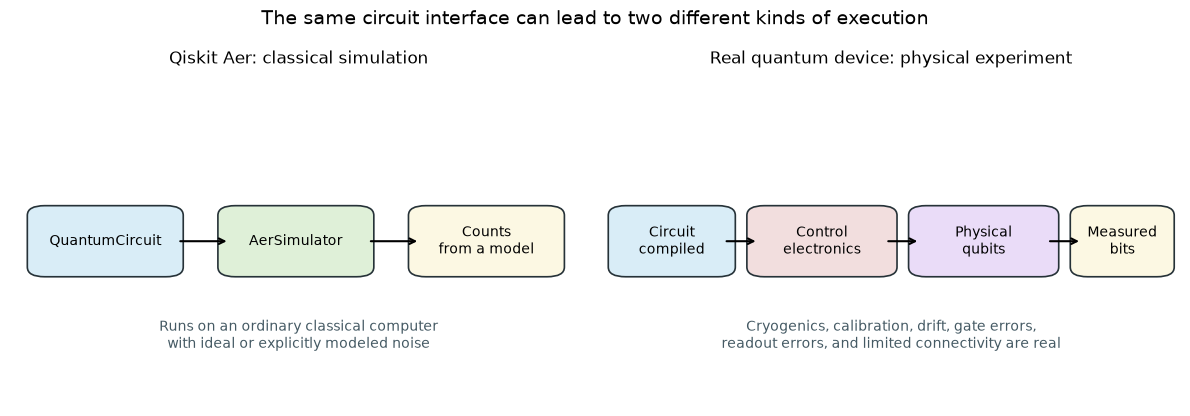

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


def add_box(axis, x, y, width, height, text, color):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1.2,
        edgecolor="#263238",
        facecolor=color,
    )
    axis.add_patch(box)
    axis.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=10)


device_figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].set_title("Qiskit Aer: classical simulation", fontsize=12, pad=14)
add_box(axes[0], 0.05, 0.42, 0.23, 0.18, "QuantumCircuit", "#d9edf7")
add_box(axes[0], 0.38, 0.42, 0.23, 0.18, "AerSimulator", "#dff0d8")
add_box(axes[0], 0.71, 0.42, 0.23, 0.18, "Counts\nfrom a model", "#fcf8e3")
axes[0].annotate("", xy=(0.38, 0.51), xytext=(0.29, 0.51), arrowprops={"arrowstyle": "->", "lw": 1.5})
axes[0].annotate("", xy=(0.71, 0.51), xytext=(0.62, 0.51), arrowprops={"arrowstyle": "->", "lw": 1.5})
axes[0].text(0.5, 0.18, "Runs on an ordinary classical computer\nwith ideal or explicitly modeled noise", ha="center", fontsize=10, color="#455a64")

axes[1].set_title("Real quantum device: physical experiment", fontsize=12, pad=14)
add_box(axes[1], 0.03, 0.42, 0.18, 0.18, "Circuit\ncompiled", "#d9edf7")
add_box(axes[1], 0.27, 0.42, 0.22, 0.18, "Control\nelectronics", "#f2dede")
add_box(axes[1], 0.55, 0.42, 0.22, 0.18, "Physical\nqubits", "#eadcf8")
add_box(axes[1], 0.83, 0.42, 0.14, 0.18, "Measured\nbits", "#fcf8e3")
for start, end in [(0.21, 0.27), (0.49, 0.55), (0.77, 0.83)]:
    axes[1].annotate("", xy=(end, 0.51), xytext=(start, 0.51), arrowprops={"arrowstyle": "->", "lw": 1.5})
axes[1].text(0.5, 0.18, "Cryogenics, calibration, drift, gate errors,\nreadout errors, and limited connectivity are real", ha="center", fontsize=10, color="#455a64")

for axis in axes:
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.axis("off")

device_figure.suptitle("The same circuit interface can lead to two different kinds of execution", fontsize=14, y=0.98)
device_figure.tight_layout()
plt.show()


## Import Libraries

We will use:

- `QuantumCircuit` to build circuits
- `AerSimulator` to simulate circuits locally
- `plot_probabilities` to visualize measured outcomes as probabilities

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

sim = AerSimulator()

### Our First Task: A Quick Foray Into `maplotlib`

The `plot_probabilities` function converts a measurement dictionary like `{'0': 750, '1': 250}` into a bar chart showing the relative frequency of each outcome.

In [4]:

def plot_probabilities(counts):
    total_shots = sum(counts.values())
    outcomes = sorted(counts)
    probabilities = [counts[outcome] / total_shots for outcome in outcomes]

    figure, axis = plt.subplots(figsize=(6, 4))
    bars = axis.bar(outcomes, probabilities, color="#2f6690")
    axis.set_ylim(0, 1.05)
    axis.set_xlabel("Measured outcome")
    axis.set_ylabel("Probability")
    axis.set_title(f"Measurement probabilities ({total_shots} shots)")
    axis.bar_label(bars, labels=[f"{probability:.1%}" for probability in probabilities], padding=3)
    figure.tight_layout()
    return axis


This is useful because quantum circuits are often run many times (`shots`) to estimate the probability distribution of the measurement results. The chart makes that distribution easy to read and compare across different circuits and experiments.

<Axes: title={'center': 'Measurement probabilities (1000 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

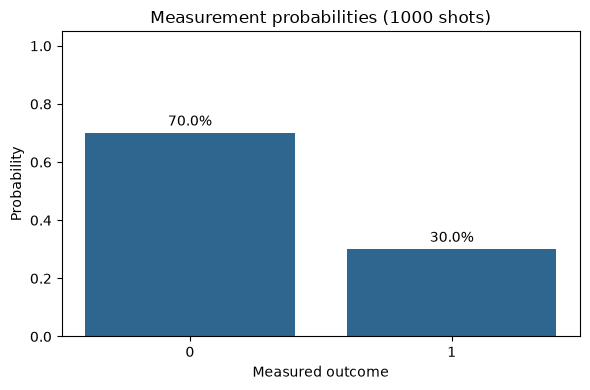

In [5]:
# Example: visualize a simple measurement distribution
example_counts = {'0': 700, '1': 300}
plot_probabilities(example_counts)


# Part 0: A Little Quantum Mechanics

Quantum mechanics is the set of rules that describes very small things such as atoms, electrons, and photons. For this tutorial, we only need a few ideas.

- **A state describes possibilities.** A quantum system has a state that lets us calculate the probabilities of different measurement results.
- **Superposition is a combination of possibilities.** Before measurement, a system can be described as a combination of states. This does not mean that we see several definite values at once.
- **Measurement gives one classical result.** When we measure, we get an ordinary outcome, such as `0` or `1`. Repeating the same experiment many times reveals the probability distribution.
- **Phase affects what combines.** Quantum states carry an additional property called phase. Phase is not directly a measurement result, but it determines whether possibilities reinforce or cancel one another. This is the source of quantum interference.
- **Entanglement links qubits together.** When two or more qubits are entangled, their joint state cannot be described by giving each qubit its own independent state. Measuring one qubit immediately tells you something about the other, even when they are far apart. This correlation is stronger than ordinary classical correlation because it arises from the shared quantum state itself.

A useful mental model is a wave: waves can overlap, strengthen one another, or cancel. Quantum mechanics uses probability amplitudes instead of ordinary wave heights, but the interference idea is similar.

These rules are different from ordinary uncertainty. A hidden classical value is not simply waiting to be revealed; the quantum state itself determines the probabilities and how they will change when operations are applied.

# From Quantum Mechanics to Quantum Computing

A **qubit** is a controllable two-level quantum system. Its two reference states are written as $\lvert 0 \rangle$ and $\lvert 1 \rangle$, which play a role similar to the values `0` and `1` of a classical bit.

Before measurement, a qubit can be in a state written as

$$
\lvert \psi \rangle = \alpha \lvert 0 \rangle + \beta \lvert 1 \rangle,
$$

where $\alpha$ and $\beta$ are probability amplitudes. They must satisfy

$$
|\alpha|^2 + |\beta|^2 = 1.
$$

The probabilities of measuring `0` and `1` are $|\alpha|^2$ and $|\beta|^2$. The amplitudes can also have phase, so two states with the same immediate measurement probabilities can behave differently after later operations.

Quantum computing turns these ideas into a programming model:

1. **Qubits hold quantum states.** A register of several qubits describes a larger state space. Two qubits have four computational-basis outcomes: `00`, `01`, `10`, and `11`.
2. **Gates change states.** Quantum gates are carefully controlled operations that change amplitudes and phases. The Hadamard gate, for example, transforms `|0>` into an equal superposition of `|0>` and `|1>`.
3. **Circuits organize operations.** A quantum program is a sequence of gates applied to qubits, followed eventually by measurement.
4. **Measurement connects to ordinary computing.** Measurement converts the quantum state into classical bits. Since each run gives one outcome, useful algorithms arrange amplitudes so that desirable outcomes become more likely through interference.
5. **Entanglement links qubits.** Some multi-qubit states cannot be described as independent states for each qubit. Operations on entangled qubits produce correlations that classical bits cannot reproduce in the same way.

This is why quantum computing is not simply classical computing with random bits. A quantum algorithm prepares amplitudes, transforms them with gates, uses interference and entanglement, and measures at the end. Qiskit lets us express that process as a circuit, simulate it, and inspect the resulting distribution of classical outcomes.

# Part 1: Classical Bits and Quantum Bits

A classical bit has one of two values:

- `0`
- `1`

A qubit can be prepared in states that do not behave like ordinary classical bits. However, when we **measure** a qubit, the result is classical: either `0` or `1`.

The simplest possible quantum circuit prepares one qubit in state `|0⟩` and measures it.

`QuantumCircuit` accepts the number of quantum and classical bits when it is created. In `QuantumCircuit(1, 1)`, the first argument creates one qubit and the second creates one classical bit. The qubit stores the quantum state, while the classical bit stores the result after measurement. For example, `QuantumCircuit(3, 2)` creates a circuit with three qubits and two classical bits.

The constructor also accepts optional settings such as `name`, which gives the circuit a descriptive label, `global_phase`, which sets the circuit's initial global phase, and `metadata`, which stores user-defined information. For larger circuits, you can also pass quantum or classical registers instead of simple counts when you want to organize bits into named groups. If the classical-bit count is omitted, the circuit contains only qubits until classical bits are added or a measurement operation supplies them.

In [6]:
qc = QuantumCircuit(1, 1)

# Measure qubit 0 into classical bit 0.
qc.measure(0, 0)

qc.draw("mpl")

MissingOptionalLibraryError: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."

In [ ]:
result = sim.run(qc, shots=1000).result()
counts = result.get_counts()

counts

{'0': 1000}

This result should be completely predictable. Since the qubit was initialized as `|0⟩` and we did not change it, every measurement should return `0`.

<Axes: title={'center': 'Measurement probabilities (1000 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

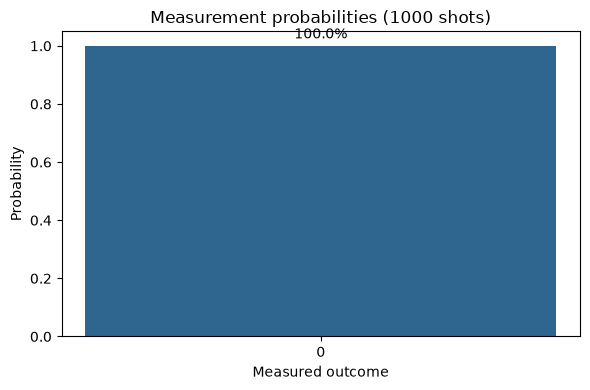

In [ ]:
plot_probabilities(counts)

This example establishes the basic structure of a Qiskit program:

1. Create a quantum circuit.
2. Apply quantum operations.
3. Measure qubits into classical bits.
4. Run the circuit many times.
5. Interpret the measurement counts.

# Part 2: Superposition with the Hadamard Gate

The **Hadamard gate**, written as `H`, is one of the most important quantum gates.

When applied to `|0⟩`, it creates a state that gives roughly equal probabilities of measuring `0` or `1`.

This is often described as **superposition**.

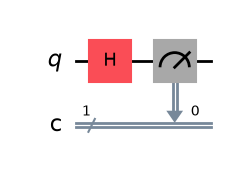

In [ ]:
qc = QuantumCircuit(1, 1)

# Put the qubit into superposition.
qc.h(0)

# Measure the qubit.
qc.measure(0, 0)

qc.draw("mpl")

In [ ]:
result = sim.run(qc, shots=1000).result()
counts = result.get_counts()

counts

{'0': 485, '1': 515}


You should see approximately half `0` results and half `1` results.

<Axes: title={'center': 'Measurement probabilities (1000 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

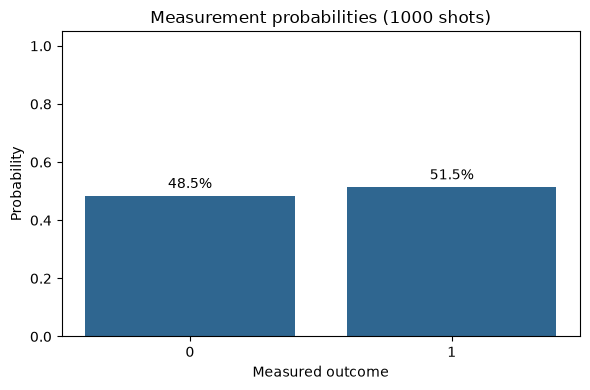

In [ ]:
plot_probabilities(counts)


The exact counts will vary because measurement is probabilistic. For example, you might see something like:

```text
{'0': 506, '1': 494}
```

The important idea is not the exact number, but the distribution.

## Try It

Change the number of shots below.

Questions:

1. What happens if you use only 10 shots?
2. What happens if you use 10,000 shots?
3. Does the result become exactly 50/50?
4. Why or why not?

In [ ]:
for shots in [10, 100, 1000, 10000]:
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    print(f"{shots} shots:", counts)

10 shots: {'1': 6, '0': 4}
100 shots: {'0': 41, '1': 59}
1000 shots: {'0': 504, '1': 496}
10000 shots: {'1': 5011, '0': 4989}


# Part 3: Entanglement with a Bell Pair

Entanglement is one of the most distinctive features of quantum information.

A simple entangled state can be created using:

1. A Hadamard gate on the first qubit.
2. A controlled-NOT gate, also called `CNOT` or `CX`.

The resulting circuit is often called a **Bell-state circuit**.

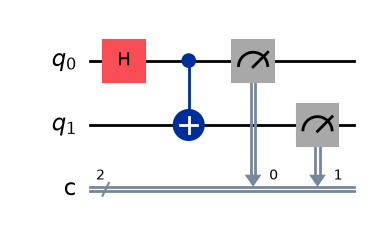

In [ ]:
qc = QuantumCircuit(2, 2)

# Put qubit 0 into superposition.
qc.h(0)

# Entangle qubit 0 with qubit 1.
qc.cx(0, 1)

# Measure both qubits.
qc.measure(0, 0)
qc.measure(1, 1)

qc.draw("mpl")

In [ ]:
result = sim.run(qc, shots=1000).result()
counts = result.get_counts()

counts

{'11': 521, '00': 479}

You should see results mostly split between:

- `00`
- `11`

You should see few or no results of:

- `01`
- `10`

The results are random, but they are correlated. If one qubit is measured as `0`, the other is also measured as `0`. If one is measured as `1`, the other is also measured as `1`.

<Axes: title={'center': 'Measurement probabilities (1000 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

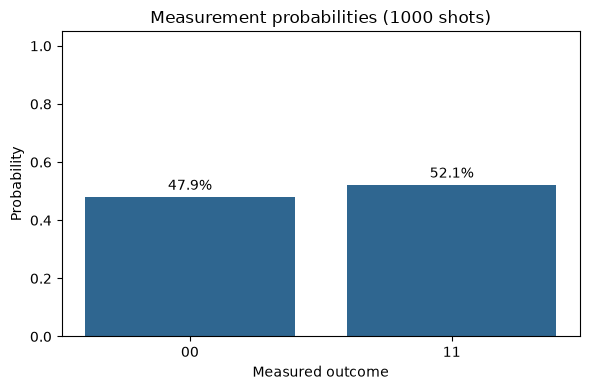

In [ ]:
plot_probabilities(counts)



This is not the same as two independent coin flips.

## A Bit of Bookkeeping: Bit Ordering in Qiskit

Qiskit displays classical bit strings with the highest-index classical bit on the left.

In this circuit:

```python
qc.measure(0, 0)
qc.measure(1, 1)
```

the printed bit string is conventionally shown as `c1c0`.

For the Bell-state example, this does not change the main interpretation because the key outcomes are `00` and `11`.

# Part 4: Interference: Quantum Computing Is Not Just Randomness

A common misconception is that quantum computing is useful because it is random.

That is not the main idea.

Quantum computing is powerful because quantum amplitudes can interfere. They can reinforce or cancel each other.

A simple way to see this is to apply two Hadamard gates in a row.

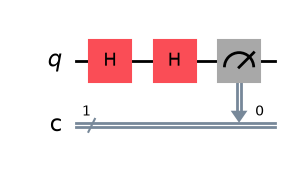

In [ ]:
qc = QuantumCircuit(1, 1)

qc.h(0)
qc.h(0)

qc.measure(0, 0)

qc.draw("mpl")

In [ ]:
result = sim.run(qc, shots=1000).result()
counts = result.get_counts()

counts

{'0': 1000}

<Axes: title={'center': 'Measurement probabilities (1000 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

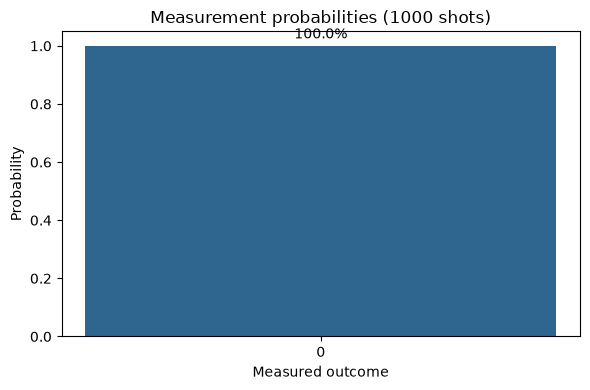

In [ ]:
plot_probabilities(counts)


One Hadamard gate gives a roughly 50/50 measurement distribution.

Two Hadamard gates return the qubit to its original state.

So the result should be:

```text
{'0': 1000}
```

This is a small example of interference. Quantum algorithms are designed so that wrong answers tend to cancel out and useful answers become more likely.

# Part 5: A Simple Quantum Coin Flip Function

The previous superposition example can be packaged as a Python function.

This demonstrates how ordinary Python code can be used to build, run, and analyze quantum circuits.

In [ ]:
def quantum_coin_flip(shots=1000):
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.measure(0, 0)

    result = sim.run(qc, shots=shots).result()
    return result.get_counts()

quantum_coin_flip(1000)

{'0': 491, '1': 509}

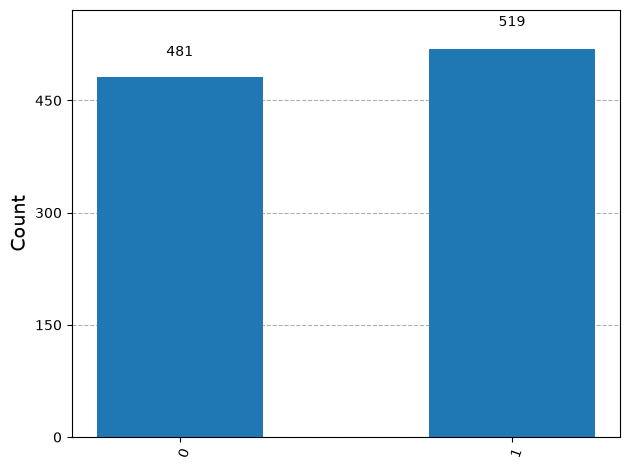

In [ ]:
plot_histogram(quantum_coin_flip(1000))


This function is useful for a demonstration, but we must be careful with the phrase "quantum coin flip."

A Hadamard circuit followed by measurement gives a balanced random result, but quantum computing is not merely a fancy random number generator.

The important follow-up question is:

> How can we arrange gates so that useful outcomes become more likely?

## Give It A Try — Change the Circuit

Modify the circuit below.

Suggestions:

1. Remove the `cx` gate and compare the result.
2. Add an `x` gate before the Hadamard.
3. Change which qubit controls the `cx` gate.
4. Increase the number of shots.

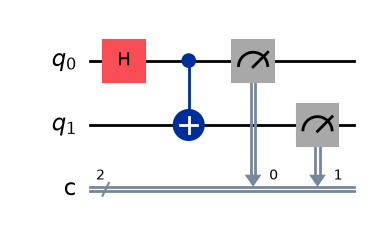

In [ ]:
challenge = QuantumCircuit(2, 2)

challenge.h(0)
challenge.cx(0, 1)

challenge.measure(0, 0)
challenge.measure(1, 1)

challenge.draw("mpl")

In [ ]:
result = sim.run(challenge, shots=1000).result()
counts = result.get_counts()

counts

{'00': 500, '11': 500}

<Axes: title={'center': 'Measurement probabilities (1000 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

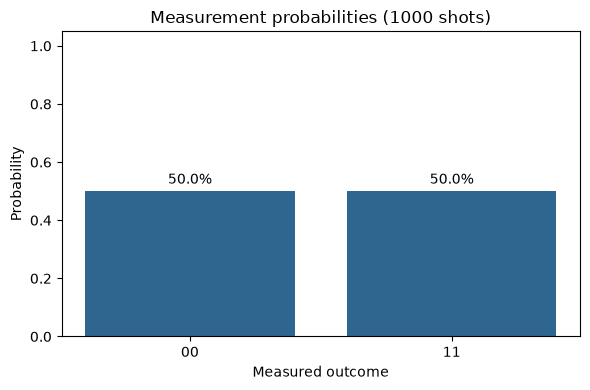

In [ ]:
plot_probabilities(counts)

# Part 6: Quantum Algorithms

The larger algorithms named above are built from the same pieces we have already seen. The following examples are intentionally small: they are not useful for solving large real-world problems, but they make the algorithmic pattern visible.

We show four different uses of a quantum circuit:

- **Deutsch-Jozsa** uses a qubit, superposition, and interference to learn about a function.
- **Grover's search** amplifies the amplitude of a marked answer.
- **Shor's factoring** uses period finding to turn a factoring problem into a quantum phase-estimation problem.
- **Quantum simulation** uses a circuit to model the time evolution of another quantum system.

These are small demonstrations for learning. They are not large, fault-tolerant implementations.

## Deutsch-Jozsa: Learning About a Function

Suppose a hidden function takes one input bit and returns one output bit. The function is promised to be either:

- **constant**: it always returns the same value
- **balanced**: it returns different values for the two possible inputs

A classical approach must test both inputs in the worst case. The Deutsch-Jozsa algorithm uses a helper qubit, superposition, and interference to distinguish these cases with one oracle query for the one-bit version.

The code below implements a balanced oracle that computes $f(x) = x$. The final measurement of the input qubit is `1`, signaling that the function is balanced.

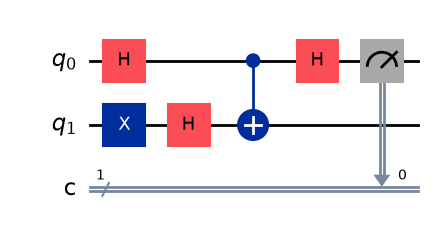

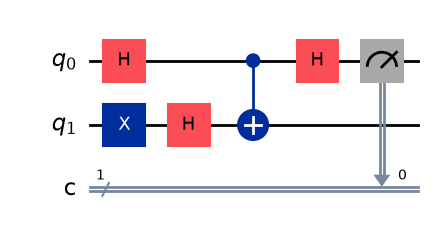

In [ ]:
from IPython.display import display
%matplotlib inline

deutsch_jozsa = QuantumCircuit(2, 1)

# Prepare the input in |+> and the helper qubit in |->.
deutsch_jozsa.h(0)
deutsch_jozsa.x(1)
deutsch_jozsa.h(1)

# Balanced oracle for f(x) = x: flip the helper when input qubit 0 is 1.
deutsch_jozsa.cx(0, 1)

# Interference reveals whether the function is constant or balanced.
deutsch_jozsa.h(0)
deutsch_jozsa.measure(0, 0)

display(deutsch_jozsa.draw(output="mpl"))

In [ ]:
dj_result = sim.run(deutsch_jozsa, shots=1000).result()
dj_counts = dj_result.get_counts()

dj_counts

{'1': 1000}

<Axes: title={'center': 'Measurement probabilities (1000 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

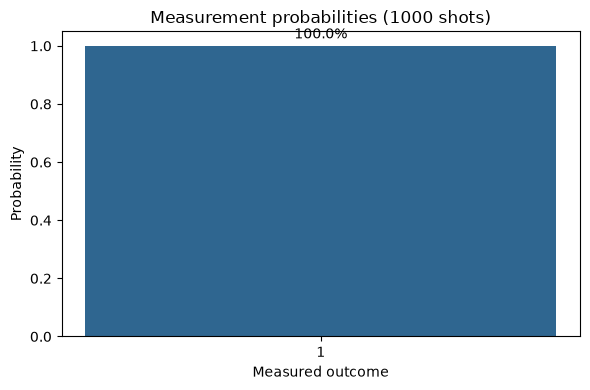

In [ ]:
plot_probabilities(dj_counts)

## Grover's Search

Grover's algorithm is often described as a quantum search algorithm. It uses a process called **amplitude amplification** to make desired answers more likely.

The key idea connects directly to this tutorial:

- superposition creates a spread of possible outcomes
- an oracle marks desirable outcomes
- interference amplifies marked outcomes

Grover's algorithm searches an unstructured space in about $\sqrt{N}$ oracle calls instead of $N$ classical checks. This two-qubit example marks `11`, then applies the diffuser to amplify that state.

Grover counts: {'11': 512}


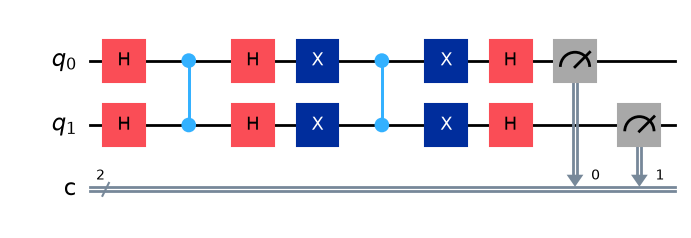

In [ ]:
grover_circuit = QuantumCircuit(2, 2)
grover_circuit.h([0, 1])

# Oracle: mark |11> by changing its phase.
grover_circuit.cz(0, 1)

# Diffuser: reflect amplitudes about their average.
grover_circuit.h([0, 1])
grover_circuit.x([0, 1])
grover_circuit.cz(0, 1)
grover_circuit.x([0, 1])
grover_circuit.h([0, 1])

grover_circuit.measure([0, 1], [0, 1])
grover_circuit.draw("mpl")
grover_counts = sim.run(grover_circuit, shots=512).result().get_counts()
print("Grover counts:", grover_counts)


<Axes: title={'center': 'Measurement probabilities (512 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

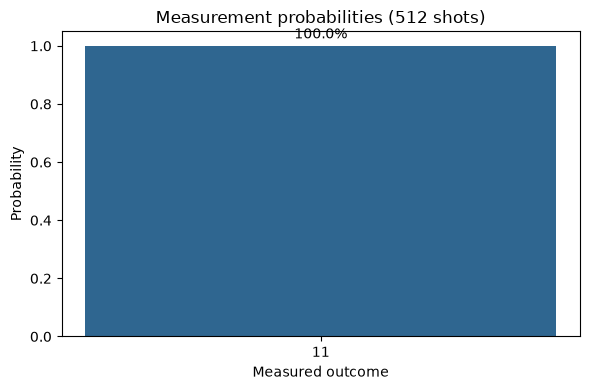

In [ ]:
plot_probabilities(grover_counts)

## Shor's Factoring: A Small Order-Finding Example

Shor's algorithm is famous because it can factor large integers efficiently on a sufficiently large fault-tolerant quantum computer.

This matters because widely used public-key cryptosystems, including RSA, rely on factoring being hard for classical computers.

However, practical attacks require much more advanced hardware than the small noisy quantum devices currently available.

Shor's algorithm factors a number by finding the period $r$ of $f(x) = a^x \bmod N$. For $N = 15$ and $a = 2$, the period is $r = 4$, and the classical step can recover factors from $\gcd(a^{r/2} \pm 1, N)$.

The cell below uses four counting qubits and four work qubits. The controlled modular-multiplication gates are represented as permutation matrices so the circuit remains readable for this small example.

In [ ]:
import math
from fractions import Fraction
import numpy as np
from qiskit import transpile
from qiskit.circuit.library import QFTGate, UnitaryGate

N = 15
a = 2
counting_qubits = 4
work_qubits = 4


def modular_multiplication_gate(multiplier, modulus, width):
    dimension = 2**width
    matrix = np.zeros((dimension, dimension), dtype=complex)
    for value in range(dimension):
        target = (multiplier * value) % modulus if value < modulus else value
        matrix[target, value] = 1
    return UnitaryGate(matrix, label=f"x{multiplier} mod {modulus}")


shor_circuit = QuantumCircuit(counting_qubits + work_qubits, counting_qubits)
shor_circuit.x(counting_qubits)  # Start the work register in |1>.
shor_circuit.h(range(counting_qubits))

for index in range(counting_qubits):
    multiplier = pow(a, 2**index, N)
    controlled_gate = modular_multiplication_gate(
        multiplier, N, work_qubits
    ).control()
    shor_circuit.append(
        controlled_gate,
        [index] + list(range(counting_qubits, counting_qubits + work_qubits)),
    )

shor_circuit.append(
    QFTGate(counting_qubits).inverse(),
    range(counting_qubits),
)
shor_circuit.measure(range(counting_qubits), range(counting_qubits))

compiled_shor = transpile(shor_circuit, sim)
shor_counts = sim.run(compiled_shor, shots=1024).result().get_counts()
print("Order-finding samples:", shor_counts)

candidate_orders = set()
for bitstring in shor_counts:
    phase = int(bitstring, 2) / 2**counting_qubits
    denominator = Fraction(phase).limit_denominator(N).denominator
    if denominator % 2 == 0 and pow(a, denominator, N) == 1:
        candidate_orders.add(denominator)

order = min(candidate_orders) if candidate_orders else None
if order is not None:
    factors = (
        math.gcd(a ** (order // 2) - 1, N),
        math.gcd(a ** (order // 2) + 1, N),
    )
    print("Candidate period:", order)
    print("Factors of 15:", factors)
else:
    print("No usable period was recovered; try more shots.")

Order-finding samples: {'1100': 247, '0000': 266, '1000': 271, '0100': 240}
Candidate period: 4
Factors of 15: (3, 5)


## Quantum Simulation: Time Evolution of a Qubit

Quantum simulation may be one of the most natural applications of quantum computing because quantum computers themselves are quantum systems.

Potential applications include:

- chemistry
- materials science
- condensed matter physics
- molecular modeling

A quantum computer can simulate another quantum system by encoding its state in qubits and applying gates that approximate time evolution. For a two-level system with Hamiltonian $H = \frac{\omega}{2}Y$, the evolution operator is $U(t) = e^{-iHt} = R_Y(\omega t)$.

The following experiment prepares `|0⟩`, evolves it for several times, and compares the simulated probability of measuring `1` with the exact formula $\sin^2(\omega t / 2)$.

Final simulated probability: 0.000


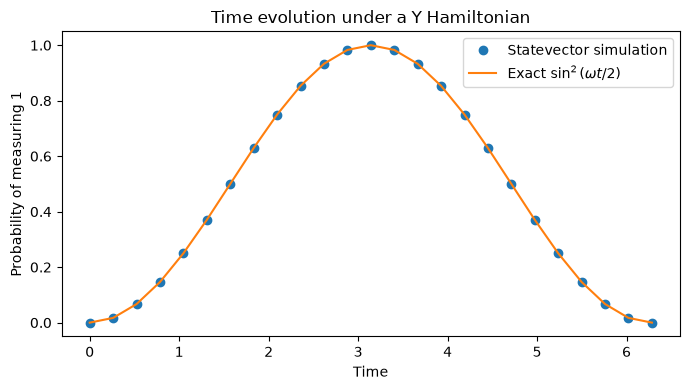

In [ ]:
from qiskit.quantum_info import Statevector

omega = 1.0
times = np.linspace(0, 2 * np.pi, 25)
simulated_probability = []
exact_probability = []

for time in times:
    evolution = QuantumCircuit(1)
    evolution.ry(omega * time, 0)
    state = Statevector.from_instruction(evolution)
    simulated_probability.append(abs(state.data[1]) ** 2)
    exact_probability.append(np.sin(omega * time / 2) ** 2)

figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(times, simulated_probability, "o", label="Statevector simulation")
axis.plot(times, exact_probability, label=r"Exact $\sin^2(\omega t / 2)$")
axis.set_xlabel("Time")
axis.set_ylabel("Probability of measuring 1")
axis.set_title("Time evolution under a Y Hamiltonian")
axis.legend()
figure.tight_layout()
print(f"Final simulated probability: {simulated_probability[-1]:.3f}")

# Part 7: Practical Limits

Current quantum computers face major engineering challenges.

Important limitations include:

- noise
- decoherence
- limited qubit counts
- imperfect gates
- measurement errors
- the need for quantum error correction

A simulator is useful for learning, but it does not fully represent the behavior of real quantum hardware.

## Small Experiments with Imperfect Hardware Models

A simulator can also model some hardware imperfections. These models are simplified, but they make the practical limits concrete:

- **Gate noise** can change a state while a gate is being applied.
- **Decoherence** can cause a state to lose information while it waits.
- **Readout error** can report the wrong classical bit even when the quantum state was prepared correctly.

The following examples compare ideal and noisy measurement distributions. In each case, the noise model is passed to `AerSimulator` explicitly, so the original ideal simulator remains available as `sim`.

### Gate Noise

A real gate is implemented by a physical control pulse, not by a perfect mathematical instruction. Imperfections in the pulse, calibration, or surrounding environment can move a qubit to the wrong state. A **depolarizing error** is a simple model for this effect: with some probability, it replaces the intended state with a randomly disturbed state.

Here the `X` gate should prepare `|1⟩`, so the ideal circuit produces only `1` outcomes. The noisy circuit can also produce `0` outcomes. Those unexpected results are evidence of an imperfect gate, not of quantum superposition in the circuit itself. Increasing the number of shots would estimate the error rate more precisely, but it would not make the gate more accurate.

In [ ]:
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

noisy_gate_circuit = QuantumCircuit(1, 1)
noisy_gate_circuit.x(0)
noisy_gate_circuit.measure(0, 0)

# A depolarizing error models a gate that sometimes disturbs the state.
gate_noise = NoiseModel()
gate_noise.add_all_qubit_quantum_error(depolarizing_error(0.10, 1), ["x"])

ideal_counts = sim.run(noisy_gate_circuit, shots=1000).result().get_counts()
noisy_counts = sim.run(
    noisy_gate_circuit, shots=1000, noise_model=gate_noise
).result().get_counts()

print("Ideal:", ideal_counts)
print("With gate noise:", noisy_counts)

Ideal: {'1': 1000}
With gate noise: {'0': 48, '1': 952}


<Axes: title={'center': 'Measurement probabilities (1000 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

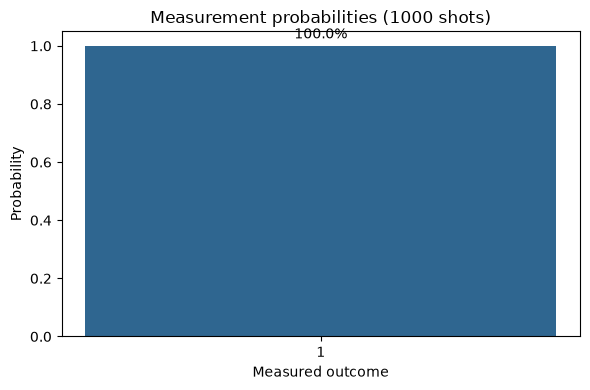

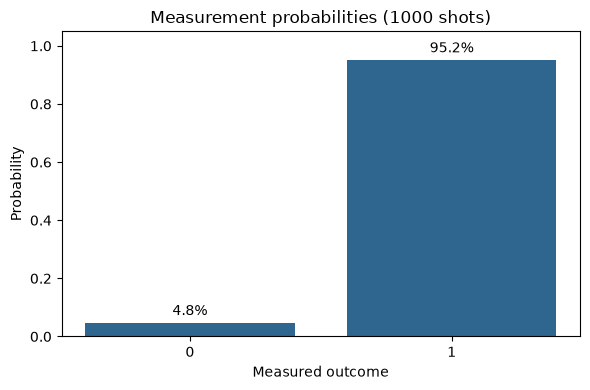

In [ ]:
plot_probabilities(ideal_counts)
plot_probabilities(noisy_counts)

### Decoherence While a Qubit Waits

The next circuit prepares `|1⟩` and then inserts idle time. A thermal-relaxation model represents energy loss and dephasing during that wait. The longer the modeled wait, the less often the excited state survives until measurement.

**Decoherence** is the loss of useful quantum behavior because a qubit interacts with its environment. The environment might be nearby electrical noise, stray radiation, temperature fluctuations, or imperfections in the control hardware. These interactions leak information about the qubit into the environment and make delicate superpositions and phase relationships harder to preserve.

Two related effects are useful to distinguish. **Relaxation** changes the qubit's energy, such as turning `|1⟩` into `|0⟩`. **Dephasing** leaves the measurement probabilities temporarily unchanged but disrupts the relative phase between parts of a superposition. Both effects can damage an algorithm: relaxation changes the answer directly, while dephasing can prevent the interference that makes a quantum algorithm useful.

In this simplified experiment, `T1` controls the characteristic energy-relaxation time and `T2` controls the loss of phase coherence. The `id` gate stands in for a period during which the qubit is waiting. The resulting mixture of `0` and `1` outcomes is not measurement randomness alone; it reflects information lost before measurement.

After modeled waiting: {'1': 611, '0': 389}


<Axes: title={'center': 'Measurement probabilities (1000 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

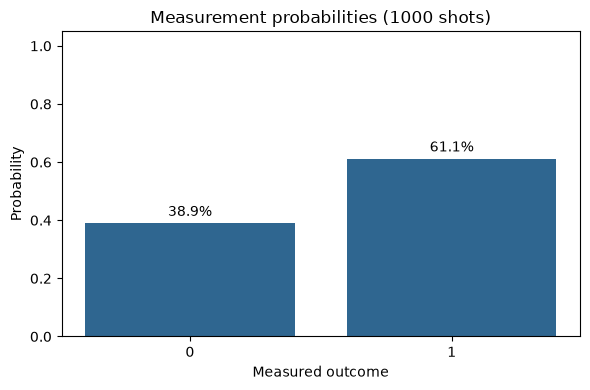

In [ ]:
from qiskit_aer.noise import thermal_relaxation_error

waiting_circuit = QuantumCircuit(1, 1)
waiting_circuit.x(0)
waiting_circuit.id(0)
waiting_circuit.measure(0, 0)

# T1 and T2 are simplified relaxation and dephasing time scales.
relaxation_noise = NoiseModel()
relaxation_noise.add_all_qubit_quantum_error(
    thermal_relaxation_error(t1=30, t2=20, time=15), ["id"]
)

relaxed_counts = sim.run(
    waiting_circuit, shots=1000, noise_model=relaxation_noise
).result().get_counts()

print("After modeled waiting:", relaxed_counts)
plot_probabilities(relaxed_counts)

### Readout Error and Repeated Shots

Readout errors happen after the quantum operations are complete. Here the qubit is deliberately prepared in `|1⟩`, but the detector is modeled as reporting `0` ten percent of the time. More shots make the estimated error rate more stable; they do not remove the detector bias.

A measurement device must convert a fragile quantum signal into an ordinary classical bit. That conversion can be imperfect: for example, a detector may fail to register an excitation or may interpret background noise as one. The matrix `[[0.90, 0.10], [0.10, 0.90]]` describes this simplified detector: a true `0` is reported as `0` 90% of the time, and a true `1` is reported as `1` 90% of the time. The remaining 10% of each row represents a flipped readout.

A **shot** is one complete repetition of the circuit, from state preparation through measurement. Because measurement is probabilistic and hardware is noisy, one shot gives only one sample. Running 1,000 shots produces a collection of samples whose counts estimate the underlying distribution. More shots reduce random sampling variation, but they do not eliminate a systematic readout bias; calibration or error-mitigation techniques are needed for that.

With readout error: {'1': 907, '0': 93}


<Axes: title={'center': 'Measurement probabilities (1000 shots)'}, xlabel='Measured outcome', ylabel='Probability'>

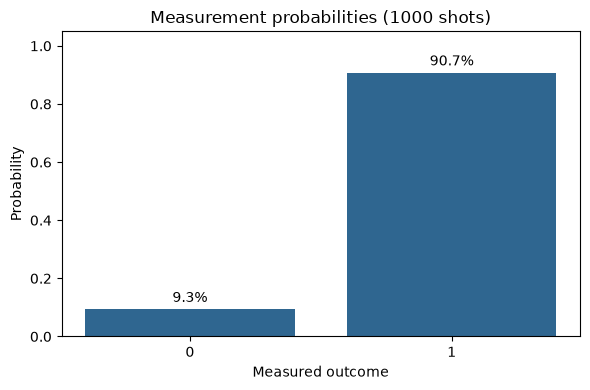

In [ ]:
readout_circuit = QuantumCircuit(1, 1)
readout_circuit.x(0)
readout_circuit.measure(0, 0)

readout_noise = NoiseModel()
readout_noise.add_all_qubit_readout_error(
    ReadoutError([[0.90, 0.10], [0.10, 0.90]])
)

readout_counts = sim.run(
    readout_circuit, shots=1000, noise_model=readout_noise
).result().get_counts()

print("With readout error:", readout_counts)
plot_probabilities(readout_counts)

### What More Shots Can and Cannot Do

Sampling uncertainty shrinks as the number of shots increases, roughly like $1 / \sqrt{N}$ for $N$ shots. Hardware errors behave differently: repeating a biased experiment gives a more precise estimate of the wrong distribution. Error mitigation and quantum error correction are needed to address those errors.

## Computational Theory: What Quantum Computing Changes

Quantum computing is best understood as a change in the kind of state space we can manipulate, not simply a faster version of classical computation.

A classical bit stores one of two values, so an $n$-bit register has $2^n$ possible classical states. A quantum register of $n$ qubits, by contrast, is represented by a vector in a Hilbert space of dimension $2^n$. This means that a quantum computer can manipulate amplitudes for all $2^n$ basis states at once through unitary transformations.

That fact is not, by itself, a guarantee of exponential speedup. The crucial point is that quantum algorithms must use interference to amplify the amplitudes of the right answers and cancel the wrong ones. This is why examples like superposition and interference are central to the tutorial: they are not just visual curiosities, they are the computational resource.

### Why this matters for complexity theory

In complexity theory, we care about how the run time scales with the input size. Quantum algorithms are often compared with classical algorithms using the same problem.

- Classical search over $N$ possibilities takes roughly $O(N)$ queries in the worst case.
- Grover's algorithm can reduce this to about $O(\sqrt{N})$ queries for unstructured search.
- Shor's algorithm can factor an integer efficiently in polynomial time on a quantum computer, while the best-known classical algorithms are subexponential but not polynomial-time in the usual sense.

This does not mean that quantum computers can solve every hard problem quickly. Most problems do not gain an exponential speedup from quantum mechanics. The real lesson is more subtle:

- quantum computers can be dramatically faster for some structured problems,
- they are not a replacement for classical computers in general,
- and the advantage depends on finding the right interference pattern.

### A simple example

This tiny code example shows how the dimension of the state space grows exponentially with qubit count:

In [ ]:
for n in [10, 20, 30, 40]:
    amplitudes = 2 ** n
    print(f"{n} qubits -> {amplitudes:,} amplitudes")
    

10 qubits -> 1,024 amplitudes
20 qubits -> 1,048,576 amplitudes
30 qubits -> 1,073,741,824 amplitudes
40 qubits -> 1,099,511,627,776 amplitudes


The output makes the core point clear: even modest numbers of qubits correspond to enormous state spaces. Quantum algorithms exploit this structure, but only if the circuit is designed so that constructive interference boosts the desired outcome and destructive interference suppresses the rest.

### Another way to say it

Quantum computing is not magic. It is a model of computation where the allowed operations are unitary transformations on quantum states, and the algorithmic power comes from controlling amplitudes rather than just bits. The challenge is to design a circuit whose interference pattern makes the answer overwhelmingly likely at measurement time.

This is the computational-theory implication of the examples in this notebook: after a qubit is in superposition, you are not merely sampling random outcomes. You are shaping a probability distribution whose structure can be engineered by gates and interference. That is the deeper reason why quantum algorithms are interesting.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2)
qc.h([0, 1])
qc.cz(0, 1)
qc.h([0, 1])

state = Statevector.from_instruction(qc)
print(state.probabilities_dict())

{np.str_('00'): np.float64(0.24999999999999983), np.str_('01'): np.float64(0.24999999999999983), np.str_('10'): np.float64(0.24999999999999983), np.str_('11'): np.float64(0.24999999999999983)}


# Summary

In this tutorial, we used Qiskit to demonstrate:

1. A measured qubit initialized to `|0⟩`.
2. Superposition using the Hadamard gate.
3. Entanglement using a Bell-state circuit.
4. Interference using two Hadamard gates.
5. A simple reusable quantum coin-flip function.
6. Grover's search with an oracle and diffuser.
7. Shor's order-finding idea for factoring 15.
8. Statevector simulation of a qubit evolving in time.

The central lesson is:

> Quantum computing is not simply faster classical computing, and it is not just randomness. It is computation based on quantum states, gates, measurement, entanglement, interference, and carefully designed algorithms.

# Suggested Next Steps

Now that we have considered quantum computing concepts, there are four follow-on Juypter Notebooks that dive deeper into the field of quantum computing:

1. [Quantum Mathematics](quantum_mathematics.ipynb) develops the state-vector, measurement, gate, interference, and entanglement mathematics behind this tutorial.
2. [Quantum Algorithms and Complexity](quantum_algorithms_and_complexity.ipynb) analyzes algorithm costs, Grover's search, Shor's period finding, and quantum complexity classes.
3. [Quantum Machine Learning](quantum_machine_learning.ipynb) introduces quantum kernels, variational circuits, training, and the evidence needed for an advantage claim.
4. [Quantum Cryptography](quantum_cryptography.ipynb) explains BB84 quantum key distribution, eavesdropping detection, security assumptions, and post-quantum cryptography.

Useful background to study alongside the notebooks includes complex numbers, vectors and matrices, probability, and linear algebra. For additional implementation practice, continue with the Qiskit tutorials and documentation.

# A Few Parting Thoughts

Allow me a moment to indulge in a few opinions on our topic of the moment. Quantum computing is in roughly the same stage that classical computing was in the late 1950s and vector processing was in the late 1990s. In each case, a conceptual shift led to a major increase in how effectively computing was used. For classical computing, that shift was the emergence of high-level languages such as FORTRAN and ALGOL. For vector processing, it was the integration of vector processing into mainstream microprocessors and the realization that GPUs could be used for general-purpose computing. Quantum computing appears to be at a similar stage of development.
